# 5. YOLOv8s-cls on the combined dataset (donor-grouped CV)

An earlier YOLO experiment scored macro-F1 0.863 on a random 85/15 split, but that split
shared 41 of 43 donors between training and test. This notebook repeats it properly:
same model, same combined dataset (847 expert labels plus 4,834 machine labels), 5-fold
cross-validation grouped by donor on the same fold partition as the ResNet runs, scored
only on the 847 expert labels.

`DEMO = True` trains fold 1 live. `FULL_RUN = True` runs all five folds and skips any fold
already finished. With both `False` the notebook is offline and shows stored results.
Evaluation is identical to the ResNet runs. Training uses the ultralytics pipeline as
shipped, so this is a comparison of two systems, not two architectures alone.


In [1]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt
from nb_style import (ROOT, p, TRAIN_COLOR, VAL_COLOR, set_seed,
                      metrics_report, verify, verify_summary)

DEMO        = False   # True -> train fold 1 live below (~30-45 min on a 6 GB GPU)
FULL_RUN    = True    # definitive run, executed on the laptop GPU, 2026-09-02
GPU         = "0"    # CUDA device index on this machine
DEMO_EPOCHS = 6

os.environ["YCVF_DEVICE"] = GPU
sys.path.insert(0, ROOT)
import yolo_cvF as yf              # machine-aware paths: laptop main checkout / garlick

%matplotlib inline
set_seed(yf.SEED)
print(f"engine: yolo_cvF.py  (seed {yf.SEED}, yolov8s-cls @{yf.IMGSZ}px, batch {yf.BATCH}, "
      f"max epochs {yf.EPOCHS}, patience {yf.PATIENCE})")
print(f"image sources: {yf.IMG_SRC}")
print(f"1024px cache:  {yf.CACHE}")
print(f"results dir:   {yf.OUT}")

engine: yolo_cvF.py  (seed 42, yolov8s-cls @640px, batch 16, max epochs 40, patience 12)
image sources: ['<repo>\\review_tool\\webapp\\review_images', '<repo>\\data_bulk\\images']
1024px cache:  <repo>\data_cache_1024
results dir:   <repo>\models\quality_yolo_cvF


## 1. The combined dataset

5,681 slides, the same set as notebook 06. Machine labels were filtered by vote
confidence. The unusable class is 6.0%.


In [2]:
c = yf.census()
print(f"dataset: {c['csv']}")
print(f"rows {c['rows']}   human {c['human']}   machine {c['machine']}   donors {c['donors']}")
print(f"labels: usable {c['usable']}   unusable {c['unusable']} "
      f"({c['unusable'] / c['rows'] * 100:.1f}%)")

dataset: combined_human_s2usable_20260828.csv
rows 5681   human 847   machine 4834   donors 43
labels: usable 5341   unusable 340 (6.0%)


## 2. The fold partition

Test donors per fold are read from the ResNet human-only run, so both models are tested on
the identical slides.


In [3]:
part = yf.fold_partition()
print(f"{'fold':>4s} {'test donors':>12s} {'test human rows':>16s} {'train rows':>11s} "
      f"{'ArmB F1':>8s}")
for f in part:
    print(f"{f['fold']:4d} {len(f['test_donors']):12d} {f['n_test_human']:16d} "
          f"{f['n_train_rows']:11d} {f['armB_macro_f1']:8.4f}")
print(f"\nsum of test rows: {sum(f['n_test_human'] for f in part)}  (= all 847 expert labels, once each)")

fold  test donors  test human rows  train rows  ArmB F1
   1            8              148        4558   0.7876
   2            9              220        4509   0.7765
   3           10              153        4553   0.8341
   4            8              151        4532   0.8042
   5            8              175        4572   0.8183

sum of test rows: 847  (= all 847 expert labels, once each)


## 3. Prepare images and fold folders

Builds a one-time 1024px image cache and the per-fold train/val/test folders (about 20
minutes the first time). Skips anything that already exists.


In [4]:
if DEMO or FULL_RUN:
    yf.prepare_images()
    yf.build_trees()
else:
    print("gates off — skipping data preparation (nothing to train this session).")

image cache ready: 5681/5681 at <= 1024px (0 newly resized)


fold1: train 3953 (+1393 dups) val 605 (87 human) test 148


fold2: train 3129 (+1246 dups) val 1380 (229 human) test 220


fold3: train 3223 (+1162 dups) val 1330 (191 human) test 153


fold4: train 3583 (+1351 dups) val 949 (209 human) test 151


fold5: train 3162 (+1169 dups) val 1410 (263 human) test 175
fold trees ready


## 4. Live training (DEMO, fold 1)


In [5]:
if DEMO:
    yf.run_fold(1, epochs=DEMO_EPOCHS, demo=True)
else:
    print("DEMO = False — skipping the live run (definitive results load in \u00a76).")

DEMO = False — skipping the live run (definitive results load in §6).


## 5. The full five-fold run


In [6]:
if FULL_RUN:
    for k in range(1, 6):
        yf.run_fold(k)
    summary = yf.aggregate()
else:
    print("FULL_RUN = False — skipping (stored results, if any, load in \u00a76).")

fold 1: already complete - skipping (delete <repo>\models\quality_yolo_cvF\fold1_done.json to re-run)
fold 2: already complete - skipping (delete <repo>\models\quality_yolo_cvF\fold2_done.json to re-run)
fold 3: already complete - skipping (delete <repo>\models\quality_yolo_cvF\fold3_done.json to re-run)
fold 4: already complete - skipping (delete <repo>\models\quality_yolo_cvF\fold4_done.json to re-run)
fold 5: already complete - skipping (delete <repo>\models\quality_yolo_cvF\fold5_done.json to re-run)
fold 1: macro-F1 0.8167 (tuned 0.7909)  unus recall 0.750  AUC 0.8761  delta vs ArmB +0.0291
fold 2: macro-F1 0.7499 (tuned 0.7238)  unus recall 0.714  AUC 0.8522  delta vs ArmB -0.0266
fold 3: macro-F1 0.8471 (tuned 0.8936)  unus recall 0.704  AUC 0.9478  delta vs ArmB +0.0130
fold 4: macro-F1 0.8055 (tuned 0.8231)  unus recall 0.857  AUC 0.9524  delta vs ArmB +0.0013
fold 5: macro-F1 0.8569 (tuned 0.8483)  unus recall 0.729  AUC 0.9126  delta vs ArmB +0.0386

AGGREGATE macro-F1 0.815

## 6. Results

Confusion matrices shaded by row fraction, with count and row percentage in each cell.


fold  macro-F1   tuned  unus.recall     AUC    n
   1    0.8167  0.7909        0.750  0.8761  148
   2    0.7499  0.7238        0.714  0.8522  220
   3    0.8471  0.8936        0.704  0.9478  153
   4    0.8055  0.8231        0.857  0.9524  151
   5    0.8569  0.8483        0.729  0.9126  175


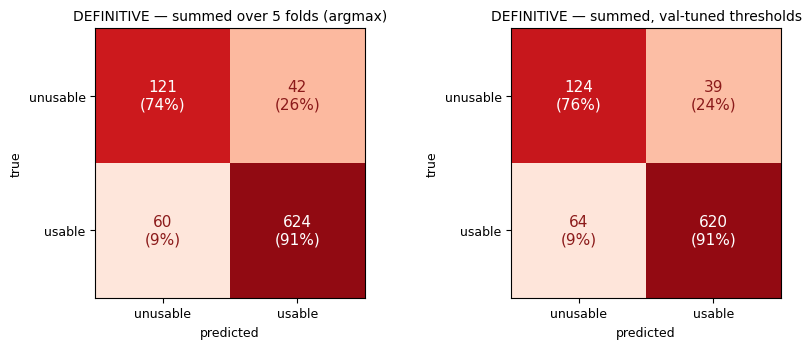

METRICS FOR REPORT - YOLOv8s-cls on Arm F combined data (DEFINITIVE, donor-grouped CV)
  macro_f1                           0.8152 +/- 0.0377
  tuned_macro_f1                     0.8159 +/- 0.057
  auc                                0.9082
  recall_unusable                    0.7509
  delta_vs_armB                      +0.0111 argmax / -0.0039 tuned
  evaluated_on                       all 847 expert labels, donor-held-out


In [7]:
def plot_confusion_rownorm(cm, title, ax, classes=("unusable", "usable")):
    cm = np.asarray(cm, dtype=int)
    frac = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(frac, cmap="Reds", vmin=0.0, vmax=1.0)
    ax.set_xticks(range(2), classes, fontsize=9)
    ax.set_yticks(range(2), classes, fontsize=9)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]}\n({frac[i, j] * 100:.0f}%)", ha="center",
                    va="center", fontsize=11, linespacing=1.2,
                    color="white" if frac[i, j] > 0.5 else VAL_COLOR)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("predicted", fontsize=9)
    ax.set_ylabel("true", fontsize=9)

cvf_path = p("models", "quality_yolo_cvF", "cv_metrics.json")
cvf = json.load(open(cvf_path, encoding="utf-8")) if os.path.exists(cvf_path) else None
if cvf is None:
    print("no definitive run stored yet — set FULL_RUN = True and run \u00a75.")
else:
    a = cvf["aggregate"]
    print(f"{'fold':>4s} {'macro-F1':>9s} {'tuned':>7s} {'unus.recall':>12s} {'AUC':>7s} {'n':>4s}")
    for f in cvf["per_fold"]:
        print(f"{f['fold']:4d} {f['macro_f1']:9.4f} {f['tuned']['macro_f1']:7.4f} "
              f"{f['recall']['unusable']:12.3f} {f['auc']:7.4f} {f['n_test']:4d}")
    fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.6))
    plot_confusion_rownorm(a["confusion_summed"], "DEFINITIVE — summed over 5 folds (argmax)", axes[0])
    plot_confusion_rownorm(a["confusion_summed_tuned"], "DEFINITIVE — summed, val-tuned thresholds", axes[1])
    fig.tight_layout(); plt.show()
    metrics_report("YOLOv8s-cls on Arm F combined data (DEFINITIVE, donor-grouped CV)",
        macro_f1=f"{a['macro_f1'][0]} +/- {a['macro_f1'][1]}",
        tuned_macro_f1=f"{a['tuned_macro_f1'][0]} +/- {a['tuned_macro_f1'][1]}",
        auc=a["auc"][0], recall_unusable=a["recall_unusable"][0],
        delta_vs_armB=f"{a['mean_delta_vs_armB_argmax']:+.4f} argmax / "
                      f"{a['mean_delta_vs_armB_tuned']:+.4f} tuned",
        evaluated_on="all 847 expert labels, donor-held-out")

## 7. The final 2x2 grid

Two architectures (ResNet-50, YOLOv8s-cls) by two training sets (847 expert labels,
5,681 combined), all under the same donor-grouped protocol. The leaky 85/15 result is
shown as a case-study row. The ResNet/combined cell is the 640px run; the 448px laptop
run from notebook 06 is listed separately.


model          training data     macro-F1 argmax    tuned
ResNet-50      human 847                  0.8041   0.8199
ResNet-50      combined 5,681             0.7775   0.7878
YOLOv8s-cls    human 847                  0.7758   0.8100
YOLOv8s-cls    combined 5,681             0.8152   0.8159
—              case study                 0.8626           <- YOLO on combined data, RANDOM 85/15 split (41/43 donors shared): the
                                                              measured cost of donor leakage vs the honest cell above
—              reproduction               0.7461   0.7218  <- the same ResNet/combined at 448px on the laptop; the 640px cell above
                                                              exceeds it by ~the measured 448-to-640 resolution effect


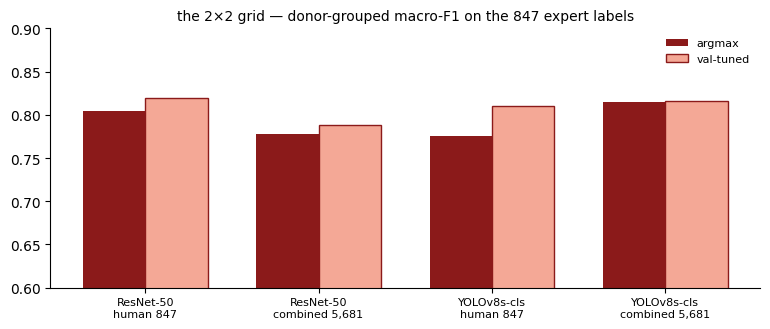

In [8]:
def cell(path, kind):
    q = p("models", path, "cv_metrics.json" if kind == "cv" else "quality_metrics.json")
    if not os.path.exists(q):
        return None
    d = json.load(open(q, encoding="utf-8"))
    if kind == "armB":
        return {"argmax": d["cnn_aggregate"]["macro_f1_mean"],
                "tuned": d["tuned_aggregate"]["macro_f1_mean"]}
    return {"argmax": d["aggregate"]["macro_f1"][0],
            "tuned": d["aggregate"]["tuned_macro_f1"][0]}

grid = {
    ("ResNet-50", "human 847"): cell("quality_union_humanonly", "armB"),
    ("ResNet-50", "combined 5,681"): cell("quality_resnet_cvF640", "cv") or cell("quality_resnet_cvF", "cv"),
    ("YOLOv8s-cls", "human 847"): cell("quality_yolo_cv847", "cv"),
    ("YOLOv8s-cls", "combined 5,681"): cell("quality_yolo_cvF", "cv"),
}
print(f"{'model':14s} {'training data':16s} {'macro-F1 argmax':>16s} {'tuned':>8s}")
for (m_, d_), v in grid.items():
    if v is None:
        print(f"{m_:14s} {d_:16s} {'(not yet run)':>16s}")
    else:
        print(f"{m_:14s} {d_:16s} {v['argmax']:16.4f} {v['tuned']:8.4f}")
print(f"{'—':14s} {'case study':16s} {'0.8626':>16s} {'':8s}  "
      f"<- YOLO on combined data, RANDOM 85/15 split (41/43 donors shared): the")
print(f"{'':14s} {'':16s} {'':16s} {'':8s}     measured cost of donor leakage vs the honest cell above")
r448 = cell("quality_resnet_cvF", "cv")
if r448 is not None and os.path.exists(p("models", "quality_resnet_cvF640", "cv_metrics.json")):
    print(f"{'—':14s} {'reproduction':16s} {r448['argmax']:16.4f} {r448['tuned']:8.4f}  "
          f"<- the same ResNet/combined at 448px on the laptop; the 640px cell above")
    print(f"{'':14s} {'':16s} {'':16s} {'':8s}     exceeds it by ~the measured 448-to-640 resolution effect")
vals = {k: v for k, v in grid.items() if v is not None}
if len(vals) == 4:
    fig, ax = plt.subplots(figsize=(7.8, 3.4))
    labels = [f"{m_}\n{d_}" for (m_, d_) in vals]
    x = np.arange(len(vals))
    ax.bar(x - 0.18, [v["argmax"] for v in vals.values()], 0.36, color=VAL_COLOR, label="argmax")
    ax.bar(x + 0.18, [v["tuned"] for v in vals.values()], 0.36, color=TRAIN_COLOR,
           edgecolor=VAL_COLOR, label="val-tuned")
    ax.set_xticks(x, labels, fontsize=8)
    ax.set_ylim(0.6, 0.9)
    ax.set_title("the 2\u00d72 grid — donor-grouped macro-F1 on the 847 expert labels", fontsize=10)
    ax.legend(fontsize=8, frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout(); plt.show()

## 8. Check against the research log


In [9]:
verify("combined rows", c["rows"], 5681, source="LOG 2026-08-28")
verify("human rows", c["human"], 847, source="LOG 2026-08-28")
verify("machine rows", c["machine"], 4834, source="LOG 2026-08-28")
verify("donors", c["donors"], 43, source="LOG 2026-08-28")
verify("fold test rows sum", sum(f["n_test_human"] for f in part), 847,
       source="donor-grouped protocol")
b = cell("quality_union_humanonly", "armB")
verify("Arm B argmax macro-F1 (re-read)", b["argmax"], 0.8041, source="LOG 2026-08-22")
verify("Arm B tuned macro-F1 (re-read)", b["tuned"], 0.8199, source="LOG 2026-09-01 correction")
r = cell("quality_resnet_cvF", "cv")
if r is not None:
    verify("ResNet/combined argmax (re-read)", r["argmax"], 0.7461, source="LOG 2026-09-02")
y847 = cell("quality_yolo_cv847", "cv")
r640 = cell("quality_resnet_cvF640", "cv")
if r640 is not None:
    verify("ResNet/combined 640px argmax (re-read)", r640["argmax"], 0.7775,
           source="LOG 2026-09-04")
if y847 is not None:
    verify("YOLO/human argmax (re-read)", y847["argmax"], 0.7758, source="LOG 2026-09-01")
if cvf is not None:
    pf = cvf["per_fold"]
    verify("this run evaluated on", int(sum(f["n_test"] for f in pf)), 847,
           source="all 847, once each")
    verify("aggregate macro-F1 (re-averaged from folds)",
           round(float(np.mean([f["macro_f1"] for f in pf])), 4),
           cvf["aggregate"]["macro_f1"][0], source="cv_metrics.json internal consistency")
verify_summary()

  ✓  combined rows: computed 5681  expected 5681   [LOG 2026-08-28]
  ✓  human rows: computed 847  expected 847   [LOG 2026-08-28]
  ✓  machine rows: computed 4834  expected 4834   [LOG 2026-08-28]
  ✓  donors: computed 43  expected 43   [LOG 2026-08-28]
  ✓  fold test rows sum: computed 847  expected 847   [donor-grouped protocol]
  ✓  Arm B argmax macro-F1 (re-read): computed 0.8041  expected 0.8041   [LOG 2026-08-22]
  ✓  Arm B tuned macro-F1 (re-read): computed 0.8199  expected 0.8199   [LOG 2026-09-01 correction]
  ✓  ResNet/combined argmax (re-read): computed 0.7461  expected 0.7461   [LOG 2026-09-02]
  ✓  ResNet/combined 640px argmax (re-read): computed 0.7775  expected 0.7775   [LOG 2026-09-04]
  ✓  YOLO/human argmax (re-read): computed 0.7758  expected 0.7758   [LOG 2026-09-01]
  ✓  this run evaluated on: computed 847  expected 847   [all 847, once each]
  ✓  aggregate macro-F1 (re-averaged from folds): computed 0.8152  expected 0.8152   [cv_metrics.json internal consistency]
